In [43]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

years = 15

endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*years)

tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [44]:
#Downloading Adjusted Close Prices
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=startDate, end=endDate)
    adj_close_df[ticker] = data['Adj Close']

print(adj_close_df)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2009-12-03   83.618980  52.068832  118.699997   38.334171   42.225758
2009-12-04   84.096260  51.853233  113.750000   38.535053   42.537754
2009-12-07   83.967484  51.990429  113.110001   38.351646   42.484474
2009-12-08   83.035660  52.075348  110.949997   38.115810   42.043098
2009-12-09   83.346260  52.023067  110.839996   38.500122   42.180099
...                ...        ...         ...         ...         ...
2024-11-21  593.669983  72.559998  246.660004  504.980011  295.049988
2024-11-22  595.510010  72.589996  249.839996  505.790009  296.510010
2024-11-25  597.530029  73.260002  242.479996  506.589996  297.959991
2024-11-26  600.650024  73.129997  242.949997  509.309998  299.049988
2024-11-27  598.830017  73.330002  243.490005  505.299988  298.200012

[3772 rows x 5 columns]


In [45]:
#Calculating Daily Log Returns and Dropping NAs
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2009-12-04  0.005692 -0.004149 -0.042596  0.005227  0.007362
2009-12-07 -0.001532  0.002642 -0.005642 -0.004771 -0.001253
2009-12-08 -0.011159  0.001632 -0.019281 -0.006168 -0.010443
2009-12-09  0.003734 -0.001004 -0.000992  0.010032  0.003253
2009-12-10  0.005620 -0.001382 -0.000180  0.004978  0.005039
...              ...       ...       ...       ...       ...
2024-11-21  0.005354 -0.000551  0.008305  0.003591  0.006972
2024-11-22  0.003095  0.000413  0.012810  0.001603  0.004936
2024-11-25  0.003386  0.009188 -0.029901  0.001580  0.004878
2024-11-26  0.005208 -0.001776  0.001936  0.005355  0.003652
2024-11-27 -0.003035  0.002731  0.002220 -0.007905 -0.002846

[3771 rows x 5 columns]


In [46]:
np.log(71.733582/71.537430)

0.0027381969292957827

In [47]:
adj_close_df.head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2009-12-03,83.618980,52.068832,118.699997,38.334171,42.225758
2009-12-04,84.096260,51.853233,113.750000,38.535053,42.537754
2009-12-07,83.967484,51.990429,113.110001,38.351646,42.484474
2009-12-08,83.035660,52.075348,110.949997,38.115810,42.043098
2009-12-09,83.346260,52.023067,110.839996,38.500122,42.180099


In [48]:
adj_close_df.shift(1).head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2009-12-03,NaN,NaN,NaN,NaN,NaN
2009-12-04,83.618980,52.068832,118.699997,38.334171,42.225758
2009-12-07,84.096260,51.853233,113.750000,38.535053,42.537754
2009-12-08,83.967484,51.990429,113.110001,38.351646,42.484474
2009-12-09,83.035660,52.075348,110.949997,38.115810,42.043098


In [49]:
#Creating an Equally Weighted Portfolio
portfolio_value = 1000000
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)

[0.2 0.2 0.2 0.2 0.2]


In [50]:
log_returns.head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2009-12-04,0.005692,-0.004149,-0.042596,0.005227,0.007362
2009-12-07,-0.001532,0.002642,-0.005642,-0.004771,-0.001253
2009-12-08,-0.011159,0.001632,-0.019281,-0.006168,-0.010443
2009-12-09,0.003734,-0.001004,-0.000992,0.010032,0.003253
2009-12-10,0.005620,-0.001382,-0.000180,0.004978,0.005039


In [51]:
sum(log_returns.iloc[0]*weights)

-0.005693139216806403

In [52]:
# Calculating Historical Portfolio Returns
historical_returns = (log_returns * weights).sum(axis =1)
print(historical_returns)

Date
2009-12-04   -0.005693
2009-12-07   -0.002111
2009-12-08   -0.009084
2009-12-09    0.003005
2009-12-10    0.002815
                ...   
2024-11-21    0.004734
2024-11-22    0.004571
2024-11-25   -0.002174
2024-11-26    0.002875
2024-11-27   -0.001767
Length: 3771, dtype: float64


In [53]:
# Finding X-Day Historical Returns
days = 50

range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)

Date
2010-02-17   -0.009339
2010-02-18    0.000975
2010-02-19    0.003191
2010-02-22    0.010782
2010-02-23   -0.001118
                ...   
2024-11-21    0.042771
2024-11-22    0.041613
2024-11-25    0.039121
2024-11-26    0.042981
2024-11-27    0.045338
Length: 3722, dtype: float64


In [54]:
# Calculating VaR Using the Historical Method
confidence_interval = 0.99

VaR = -np.percentile(range_returns, 100 - (confidence_interval * 100))*portfolio_value
print(VaR)

109874.75014790852


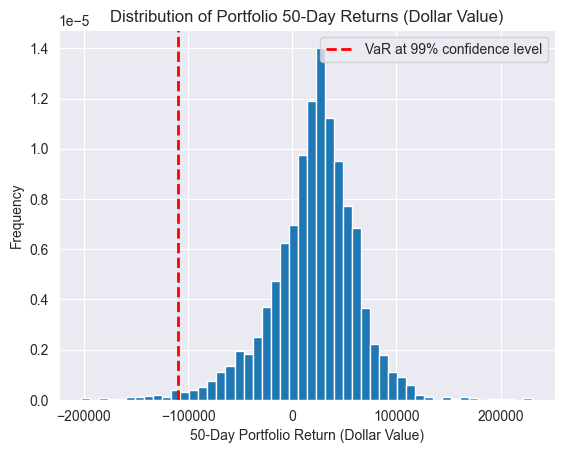

In [55]:
#Plotting the Results of the Historical Returns
return_window = days
range_returns = historical_returns.rolling(window=return_window).sum()
range_returns = range_returns.dropna()

range_returns_dollar = range_returns * portfolio_value

plt.hist(range_returns_dollar.dropna(), bins=50, density=True)
plt.xlabel(f'{return_window}-Day Portfolio Return (Dollar Value)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {return_window}-Day Returns (Dollar Value)')
plt.axvline(-VaR, color='r', linestyle='dashed', linewidth=2, label=f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()